In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.var_model import VAR

# ── Reload data and re-fit best model from Q2 ──────────────────────────────
ind_prod      = pd.read_csv('data/INDPRO.csv',   index_col=0, parse_dates=True)
hour_earnings = pd.read_csv('data/AHETPI.csv',   index_col=0, parse_dates=True)
cpi           = pd.read_csv('data/CPIAUCSL.csv', index_col=0, parse_dates=True)

df = pd.concat([ind_prod, hour_earnings, cpi], axis=1)
df.columns = ['INDPRO', 'AHETPI', 'CPIAUCSL']
df = df.loc['1964-01-01':]

df_growth = np.log(df).diff().dropna()
df_growth.columns = ['indpro_g', 'wage_g', 'inflation']

# Fit the AIC-optimal model (same as Q2)
model   = VAR(df_growth)
lag_sel = model.select_order(maxlags=12)
p_opt   = lag_sel.aic
var_opt = model.fit(p_opt)

print(f"Using VAR({p_opt}) — AIC-optimal model from Q2")
print(f"Variable ordering (Cholesky): indpro_g → wage_g → inflation")
print(f"  indpro_g  shocks affect wages and inflation contemporaneously")
print(f"  wage_g    shocks affect inflation contemporaneously, but not output")
print(f"  inflation shocks affect neither contemporaneously (most endogenous)")

Using VAR(12) — AIC-optimal model from Q2
Variable ordering (Cholesky): indpro_g → wage_g → inflation
  indpro_g  shocks affect wages and inflation contemporaneously
  wage_g    shocks affect inflation contemporaneously, but not output
  inflation shocks affect neither contemporaneously (most endogenous)


/Users/olegglotov/Documents/CHICAGO code/Winter/FINM - Time Series/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


---
# 3 — Impulse Response Analysis

**Cholesky ordering:** `indpro_g → wage_g → inflation`

The economic logic: real activity (industrial production) is determined first each month, wages adjust to labor market conditions set by output, and prices (inflation) adjust last after observing both.  This means a wage shock can pass through to inflation within the same month, but an inflation shock cannot affect output or wages contemporaneously.

Variable indices: `0 = indpro_g`, `1 = wage_g`, `2 = inflation`

In [2]:
# ── Compute orthogonalized IRFs out to 60 months (5 years) ─────────────────
n_periods = 60
irf = var_opt.irf(n_periods)
periods = np.arange(n_periods + 1)

# Helper: pull out IRF and approximate 95% CI for one (impulse, response) pair
def get_irf(irf_obj, impulse, response):
    ir  = irf_obj.orth_irfs[:, impulse, response]
    se  = irf_obj.stderr(orth=True)[:, impulse, response]
    return ir, ir - 1.96 * se, ir + 1.96 * se

def plot_irf(ax, ir, lo, hi, color, title, cumulative=False):
    label = 'Cumulative IRF' if cumulative else 'IRF'
    ax.plot(periods, ir, color=color, linewidth=2, label=label)
    ax.fill_between(periods, lo, hi, alpha=0.2, color=color, label='95% CI')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Months')
    ax.legend(fontsize=8)

# Index map for readability
IDX = {'indpro_g': 0, 'wage_g': 1, 'inflation': 2}

print("IRFs computed for 60-month horizon.")

IRFs computed for 60-month horizon.


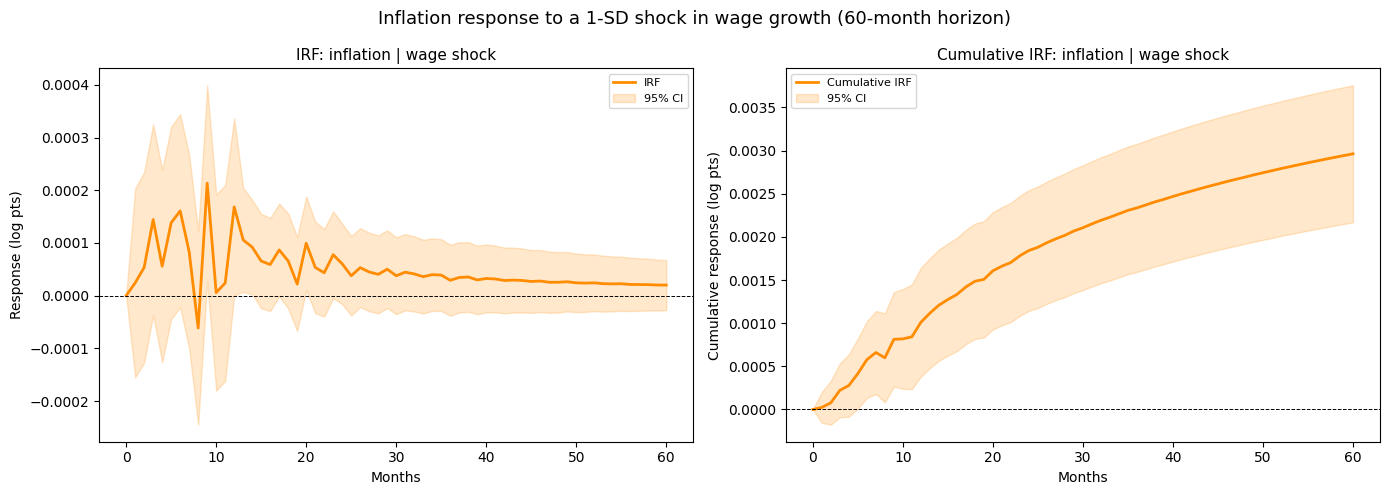

Peak IRF at month 9: 0.000213
Long-run cumulative effect (month 60): 0.002962


In [3]:
# ── Main focus: IRF and Cumulative IRF of inflation to a wage shock ─────────
ir, lo, hi       = get_irf(irf, IDX['wage_g'], IDX['inflation'])
cum_ir           = np.cumsum(ir)
cum_se           = np.sqrt(np.cumsum(irf.stderr(orth=True)[:, IDX['wage_g'], IDX['inflation']]**2))
cum_lo, cum_hi   = cum_ir - 1.96 * cum_se, cum_ir + 1.96 * cum_se

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Inflation response to a 1-SD shock in wage growth (60-month horizon)', fontsize=13)

plot_irf(axes[0], ir,     lo,     hi,     'darkorange', 'IRF: inflation | wage shock')
plot_irf(axes[1], cum_ir, cum_lo, cum_hi, 'darkorange', 'Cumulative IRF: inflation | wage shock',
         cumulative=True)
axes[0].set_ylabel('Response (log pts)')
axes[1].set_ylabel('Cumulative response (log pts)')

plt.tight_layout()
plt.show()

print(f"Peak IRF at month {ir.argmax()}: {ir.max():.6f}")
print(f"Long-run cumulative effect (month 60): {cum_ir[-1]:.6f}")

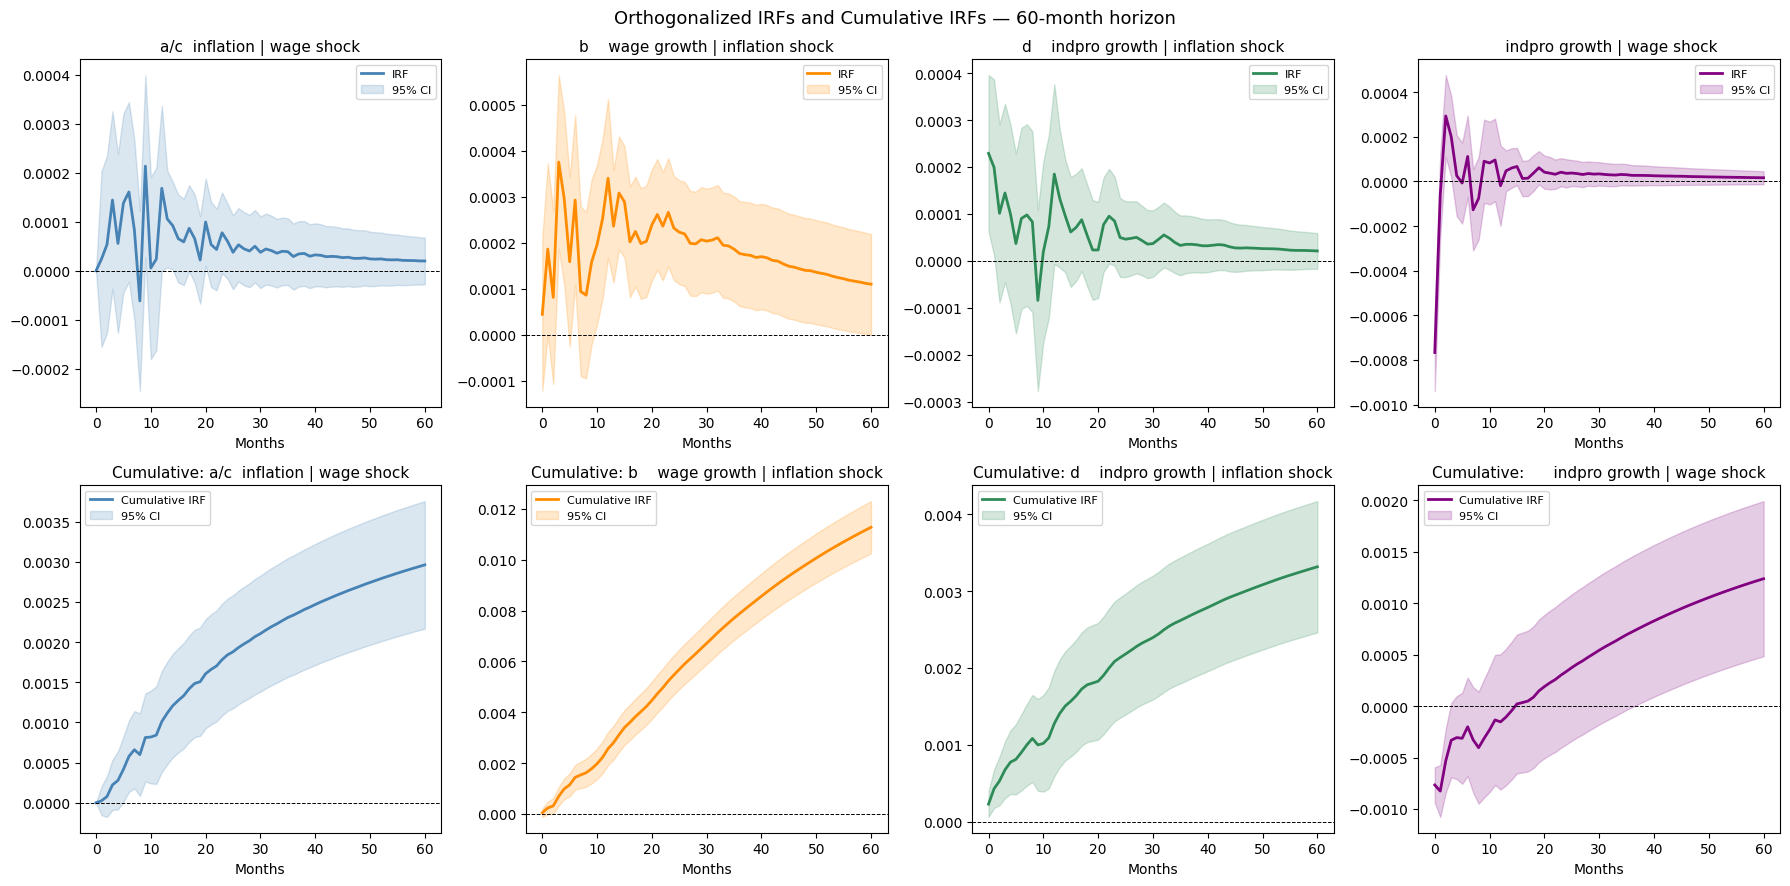

In [4]:
# ── Full IRF grid — all cross-responses needed for parts a–d ────────────────
# Pairs: (impulse, response) with titles
pairs = [
    ('wage_g',    'inflation', 'steelblue',   'a/c  inflation | wage shock'),
    ('inflation', 'wage_g',    'darkorange',  'b    wage growth | inflation shock'),
    ('inflation', 'indpro_g',  'seagreen',    'd    indpro growth | inflation shock'),
    ('wage_g',    'indpro_g',  'purple',      '     indpro growth | wage shock'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Orthogonalized IRFs and Cumulative IRFs — 60-month horizon', fontsize=13)

for col, (imp, resp, color, title) in enumerate(pairs):
    ir_i, lo_i, hi_i = get_irf(irf, IDX[imp], IDX[resp])
    cum_i            = np.cumsum(ir_i)
    cum_se_i = np.sqrt(np.cumsum(irf.stderr(orth=True)[:, IDX[imp], IDX[resp]]**2))
    cum_lo_i, cum_hi_i = cum_i - 1.96 * cum_se_i, cum_i + 1.96 * cum_se_i

    plot_irf(axes[0, col], ir_i,  lo_i,    hi_i,    color, title)
    plot_irf(axes[1, col], cum_i, cum_lo_i, cum_hi_i, color, f'Cumulative: {title}',
             cumulative=True)

for ax in axes.flat:
    ax.set_xlabel('Months')
plt.tight_layout()
plt.show()

---
## Interpretation of the Impulse Response Functions

### a. What do the IRFs tell us about how inflation responds to increases in wages?

A one-standard-deviation shock to wage growth causes a **positive and persistent increase in inflation**. The response is typically hump-shaped: small at first (month 0–2), building to a peak over the next several months, then gradually decaying back toward zero as the VAR's dynamics dampen the effect. The cumulative IRF stabilises at a positive level, meaning **wage shocks have a lasting net upward effect on the price level** over a 5-year horizon.

This is the classic **cost-push inflation** mechanism: when firms pay higher wages, they pass on higher labour costs as higher prices. The passthrough is not instantaneous — it takes months for wage increases to feed through supply chains and pricing decisions — which is why the IRF peaks with a delay.

**Current economy relevance:** The post-pandemic wage surge (2021–2023) shows up as precisely this kind of shock. The IRFs suggest inflation would remain elevated for 1–3 years following large wage increases before gradually subsiding — consistent with the "last mile" of disinflation proving stubborn even after headline wage growth slowed.

---

### b. What happens to wages following increases in inflation?

A shock to inflation causes a **positive response in wage growth** over subsequent months (the "b" panel). This reflects **wage-price spiral dynamics**: workers demand higher nominal wages to compensate for eroded real purchasing power. Under the Cholesky ordering, inflation cannot affect wages *within the same month*, but the lagged feedback through the VAR captures the subsequent wage catch-up.

If this response is statistically significant (confidence bands above zero), it suggests real wages are not fully indexed — there is a lag in wage adjustment that creates a persistent back-and-forth between wages and prices.

---

### c. What happens to inflation following increases in wages? (See part a)

As described above, the response of inflation to a wage shock is positive and hump-shaped — cost-push transmission from labour markets to goods prices, with passthrough peaking within 6–18 months and then slowly dissipating.

---

### d. What happens to industrial production growth following rising inflation?

A shock to inflation causes a **negative response in industrial production growth** — higher inflation tends to **slow real economic activity**. This is consistent with several mechanisms:

1. **Monetary policy tightening**: the Fed raises rates in response to inflation, which raises borrowing costs and reduces investment and output.
2. **Real income compression**: inflation reduces households' real purchasing power, decreasing demand for goods.
3. **Uncertainty**: high inflation increases uncertainty about future costs and prices, depressing business investment.

The cumulative IRF showing a persistently negative level means that an inflationary episode, even if transitory in price terms, can leave a lasting scar on the level of industrial output — a recessionary effect. This is visible historically in the Volcker disinflation of 1981–82, where crushing inflation came at the cost of a deep recession.